
# Lab_4: FDM-capacitor

### Potential and Electric field from a capacitor

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" width="500" height="300" />

### Solucion numerica con diferencias finitas (FDM)

Se discretiza la ecuacion de Laplace en una malla cuadrada y se resuelve con el metodo de **Jacobi**. Las placas del capacitor se modelan como dos segmentos verticales con potencial fijo (+V y -V).

Convergencia en 6034 iteraciones con error maximo 9.99e-06


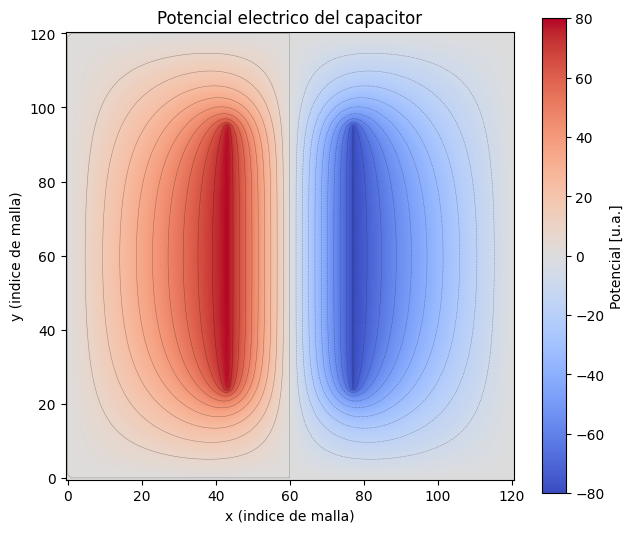

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def make_capacitor_domain(n=121, plate_voltage=80.0):
    """Build grid, plate masks, and fixed-potential matrix."""
    phi0 = np.zeros((n, n), dtype=float)

    # Geometria elegida para diferir del ejemplo base
    y_start, y_end = int(0.2 * n), int(0.8 * n)
    x_left = int(0.36 * n)
    x_right = int(0.64 * n)

    left_plate = np.zeros_like(phi0, dtype=bool)
    right_plate = np.zeros_like(phi0, dtype=bool)

    left_plate[y_start:y_end, x_left] = True
    right_plate[y_start:y_end, x_right] = True

    fixed_mask = left_plate | right_plate
    phi0[left_plate] = plate_voltage
    phi0[right_plate] = -plate_voltage

    return phi0, fixed_mask


def solve_laplace_jacobi(phi0, fixed_mask, tol=1e-5, max_iter=30_000):
    """Jacobi solver for Laplace equation in 2D."""
    phi = phi0.copy()
    phi_next = phi.copy()

    last_err = np.inf
    for k in range(1, max_iter + 1):
        phi_next[1:-1, 1:-1] = 0.25 * (
            phi[2:, 1:-1] + phi[:-2, 1:-1] + phi[1:-1, 2:] + phi[1:-1, :-2]
        )

        # Reaplicar los valores fijos de las placas
        phi_next[fixed_mask] = phi0[fixed_mask]

        last_err = np.max(np.abs(phi_next - phi))
        phi, phi_next = phi_next, phi

        if last_err < tol:
            return phi, k, last_err

    return phi, max_iter, last_err


# 1) Construccion de la malla
phi0, fixed_mask = make_capacitor_domain(n=121, plate_voltage=80.0)

# 2) Solucion de Laplace
phi, n_iter, err = solve_laplace_jacobi(phi0, fixed_mask, tol=1e-5, max_iter=30_000)
print(f"Convergencia en {n_iter} iteraciones con error maximo {err:.2e}")

# 3) Visualizacion del potencial
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(phi, origin="lower", cmap="coolwarm", interpolation="bicubic")
ax.contour(phi, levels=20, colors="black", linewidths=0.35, alpha=0.35)
ax.set_title("Potencial electrico del capacitor")
ax.set_xlabel("x (indice de malla)")
ax.set_ylabel("y (indice de malla)")
plt.colorbar(im, ax=ax, label="Potencial [u.a.]")
plt.tight_layout()
plt.show()

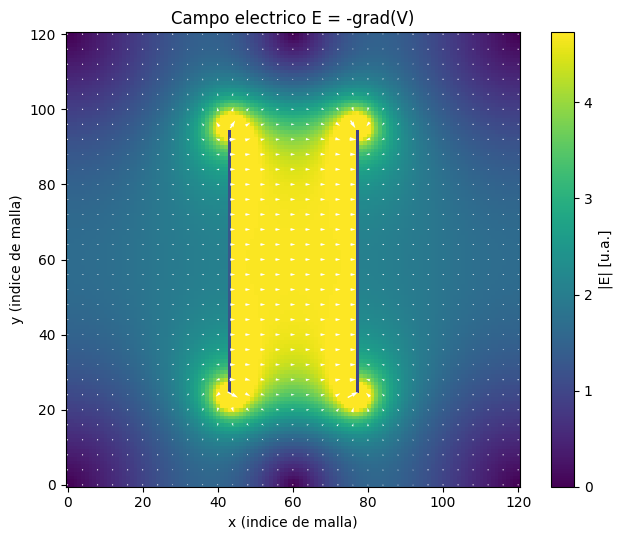

Valor maximo de |E|: 12.250
Valor promedio de |E|: 2.203


In [2]:
# Campo electrico numerico: E = -grad(phi)
dphi_dy, dphi_dx = np.gradient(phi)
Ex = -dphi_dx
Ey = -dphi_dy
E_mag = np.hypot(Ex, Ey)

# Escala para mejorar visibilidad
E_clip = np.clip(E_mag, 0, np.percentile(E_mag, 95))

# Submuestreo para vectores
step = 4
y_idx, x_idx = np.indices(phi.shape)

fig, ax = plt.subplots(figsize=(7.0, 5.5))
bg = ax.imshow(E_clip, origin="lower", cmap="viridis")
ax.quiver(
    x_idx[::step, ::step],
    y_idx[::step, ::step],
    Ex[::step, ::step],
    Ey[::step, ::step],
    color="white",
    pivot="mid",
    scale=430,
    width=0.003,
)

ax.set_title("Campo electrico E = -grad(V)")
ax.set_xlabel("x (indice de malla)")
ax.set_ylabel("y (indice de malla)")
plt.colorbar(bg, ax=ax, label="|E| [u.a.]")
plt.tight_layout()
plt.show()

print(f"Valor maximo de |E|: {E_mag.max():.3f}")
print(f"Valor promedio de |E|: {E_mag.mean():.3f}")

NOTA: Buen trabajo.El campo electrico no se visualiza bien con ax.quiver. Para calcular el campo electrico se debe usa diferencias finitas o la derivada central... np.gradient() quemétodo usa?
Nota 4.7